# FUSE Stage 0 — FLUX.1 Fill [dev] 4-bit reference hypotheses

This notebook creates **synthetic intact-reference hypotheses** from a
photograph of a damaged object. It uses the mask-conditioned
`black-forest-labs/FLUX.1-Fill-dev` pipeline: black mask pixels are
protected and white mask pixels are generated.

The result is not measured evidence or historical ground truth. FUSE
keeps several seeded alternatives, records their provenance, and
requires an explicit human selection before publishing an image to
Hunyuan.

## One-time model-access requirement

1. Sign in to Hugging Face and open
   <https://huggingface.co/black-forest-labs/FLUX.1-Fill-dev>.
2. Accept the FLUX.1 dev license/access conditions.
3. Create a Hugging Face **read** token.
4. On the host, run `export HF_TOKEN='hf_...'` before recreating the
   container. Never paste the token into this notebook or commit it.

FLUX.1 Fill [dev] uses gated, non-commercial model weights. Review the
license and the hackathon rules before use.


In [1]:
import gc
import hashlib
import importlib.metadata as metadata
import json
import os
import shutil
import sys
import time
from collections import deque
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
from diffusers import (
    BitsAndBytesConfig as DiffusersBitsAndBytesConfig,
    FluxFillPipeline,
    FluxTransformer2DModel,
)
from huggingface_hub import get_token, whoami
from IPython.display import display
from PIL import Image, ImageDraw, ImageFilter, PngImagePlugin
from transformers import (
    BitsAndBytesConfig as TransformersBitsAndBytesConfig,
    T5EncoderModel,
)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("Diffusers:", metadata.version("diffusers"))
print("Transformers:", metadata.version("transformers"))
print("bitsandbytes:", metadata.version("bitsandbytes"))
print(f"Host RAM: {psutil.virtual_memory().total / 2**30:.1f} GiB")

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. Verify the NVIDIA driver, Docker NVIDIA "
        "runtime, and the container's `gpus: all` setting."
    )

print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU VRAM:",
    f"{torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GiB",
)
print("BF16 supported:", torch.cuda.is_bf16_supported())


Python: 3.11.13
PyTorch: 2.7.1+cu128
CUDA runtime: 12.8
Diffusers: 0.39.0
Transformers: 4.57.6
bitsandbytes: 0.50.1
Host RAM: 31.1 GiB
GPU: NVIDIA GeForce RTX 4080 Laptop GPU
GPU VRAM: 11.6 GiB
BF16 supported: True


## Adaptive CV restoration mask

`MASK_MODE = "auto"` is the default. It adapts the mask to each new damaged
photograph instead of reusing fixed pixel coordinates. The detector:

1. estimates the background colour from the image border;
2. segments the largest foreground object;
3. finds bright, low-saturation regions exposed at the object boundary;
4. selects the most compact fracture-surface candidate;
5. estimates the fracture cross-section and outward tail direction; and
6. constructs a tapered continuation mask in that local coordinate system.

This is designed for the FUSE/Pogo acquisition setup: one object against a
plain, contrasting background with a visible pale fracture surface. It raises
an error instead of silently guessing when the best candidate is ambiguous.
In that case, set the optional coarse `FRACTURE_HINT_NORMALIZED`, or use
`MASK_MODE = "custom"` with a same-size grayscale PNG. White means generate;
black means preserve.


In [ ]:
MODEL_ID = "black-forest-labs/FLUX.1-Fill-dev"

FUSE_ROOT = Path("/workspace") if Path("/workspace/data").exists() else Path.cwd().resolve()
DATA_ROOT = FUSE_ROOT / "data"

INPUT_IMAGE = DATA_ROOT / "scenes" / "reference" / "broken_ref.png"
PREVIOUS_SYNTHETIC = DATA_ROOT / "scenes" / "reference" / "broken_ref.png"

# Mask selection: "auto" (recommended), "custom", or "polygon".
MASK_MODE = "auto"

# Used only with MASK_MODE="custom". Must be a same-size grayscale PNG.
CUSTOM_MASK_PATH = None

# Optional coarse hint used only to disambiguate automatic detection. This is
# a normalized (x, y) point near the fracture, not a hand-drawn mask. Leave at
# None for fully automatic selection. Example: (0.78, 0.44).
FRACTURE_HINT_NORMALIZED = None

# Automatic CV detector. Thresholds intentionally describe the acquisition
# conditions rather than the current image's absolute position or resolution.
AUTO_BACKGROUND_BORDER_FRACTION = 0.025
AUTO_BACKGROUND_MIN_DISTANCE = 24.0
AUTO_PALE_VALUE_MIN = 190.0
AUTO_PALE_SATURATION_MAX = 0.18
AUTO_MIN_COMPONENT_AREA_PX = 20
AUTO_MIN_BOUNDARY_FRACTION = 0.20
AUTO_MIN_COMPACTNESS = 0.18
AUTO_CONFIDENCE_RATIO = 1.25

# Geometry of the generated continuation, expressed relative to the detected
# fracture width, so it follows image scale and camera framing automatically.
AUTO_MASK_LENGTH_BASE_WIDTHS = 2.7
AUTO_MASK_OVERLAP_BASE_WIDTHS = 0.35
AUTO_MASK_WIDTH_SCALE = 1.15
AUTO_MASK_CURVATURE_BASE_WIDTHS = 0.0

# Legacy normalized polygon, retained as an explicit fallback only. Select it
# with MASK_MODE="polygon"; it is tailored to the original Pogo photograph.
MASK_POLYGON_NORMALIZED = [
    (0.764, 0.462),
    (0.770, 0.420),
    (0.772, 0.360),
    (0.760, 0.330),
    (0.776, 0.310),
    (0.781, 0.250),
    (0.790, 0.190),
    (0.801, 0.250),
    (0.807, 0.330),
    (0.811, 0.410),
    (0.815, 0.462),
]

# The model receives the binary mask. Feathering is used only when the
# generated crop is composited back into the exact source photograph.
FEATHER_RADIUS_PX = 8

# A padded crop makes the fracture larger in model space while retaining
# enough surrounding tail/back context to infer glaze, lighting and form.
AUTO_CROP_TO_MASK = True
CROP_PADDING_PX = 160
MODEL_MAX_SIDE = 640
MODEL_MAX_AREA = 640 * 640
MODEL_SIZE_MULTIPLE = 16

PROMPT = """
Fill only the white masked region to reconstruct the missing tail tip of
exactly the same glossy hand-painted ceramic green dragon figurine.
Continue the surviving green tail directly through the visible fracture
in its current nearly vertical upward tangent. The new part must be one
continuous green ceramic volume with matching starting thickness, glaze,
highlights, camera perspective and a gradual natural taper. Continue one
small dark-navy dorsal spike along the outer edge, following the existing
spike rhythm. End in an integrated moderately pointed green ceramic tip.
The junction must look physically continuous and the black background
must remain black. Do not attach a cap, cone, horn, pencil point, white
object or navy terminal cap. Do not redesign the dragon or alter any
protected part of the photograph.
""".strip()

# Start with one seed for a smoke test, then restore all four.
SEEDS = [17]
SELECTED_SEED = 17

# Fill's official example uses 50 steps and guidance 30. Thirty steps is
# the practical 12 GB smoke-test default; use 50 for final candidates.
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 30.0
MAX_SEQUENCE_LENGTH = 128

# Model-level CPU offload is required by this 4-bit loading path. Sequential
# offload can move bitsandbytes quantization state to the meta device.
OFFLOAD_MODE = "model"

RUN_NAME = "reference_fill_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
RUN_DIR = DATA_ROOT / "flux_outputs" / "runs" / RUN_NAME
RAW_DIR = RUN_DIR / "raw_candidates"
CANDIDATE_DIR = RUN_DIR / "constrained_candidates"
SELECTED_DIR = RUN_DIR / "selected"

# Publishing is always a separate, explicit human decision.
PUBLISH_TO_HUNYUAN = False
HUNYUAN_INPUT = DATA_ROOT / "scenes" / "reference" / "intact_ref.png"

print("Input:", INPUT_IMAGE)
print("Run:", RUN_DIR)
print("Seeds:", SEEDS)
print("Mask mode:", MASK_MODE)
print("Offload mode:", OFFLOAD_MODE)


Input: /workspace/data/scenes/global/reference/pogo_incomplete.png
Run: /workspace/data/flux_outputs/runs/reference_fill_20260820T202705Z
Seeds: [17]
Mask mode: auto
Offload mode: model


Damaged input size: (1920, 1080)
Damaged input SHA-256: 8f5ec8ee0467b2efa4c488fedb6e4f0da026892065e1b5e1c0b4e32d6a2b7757


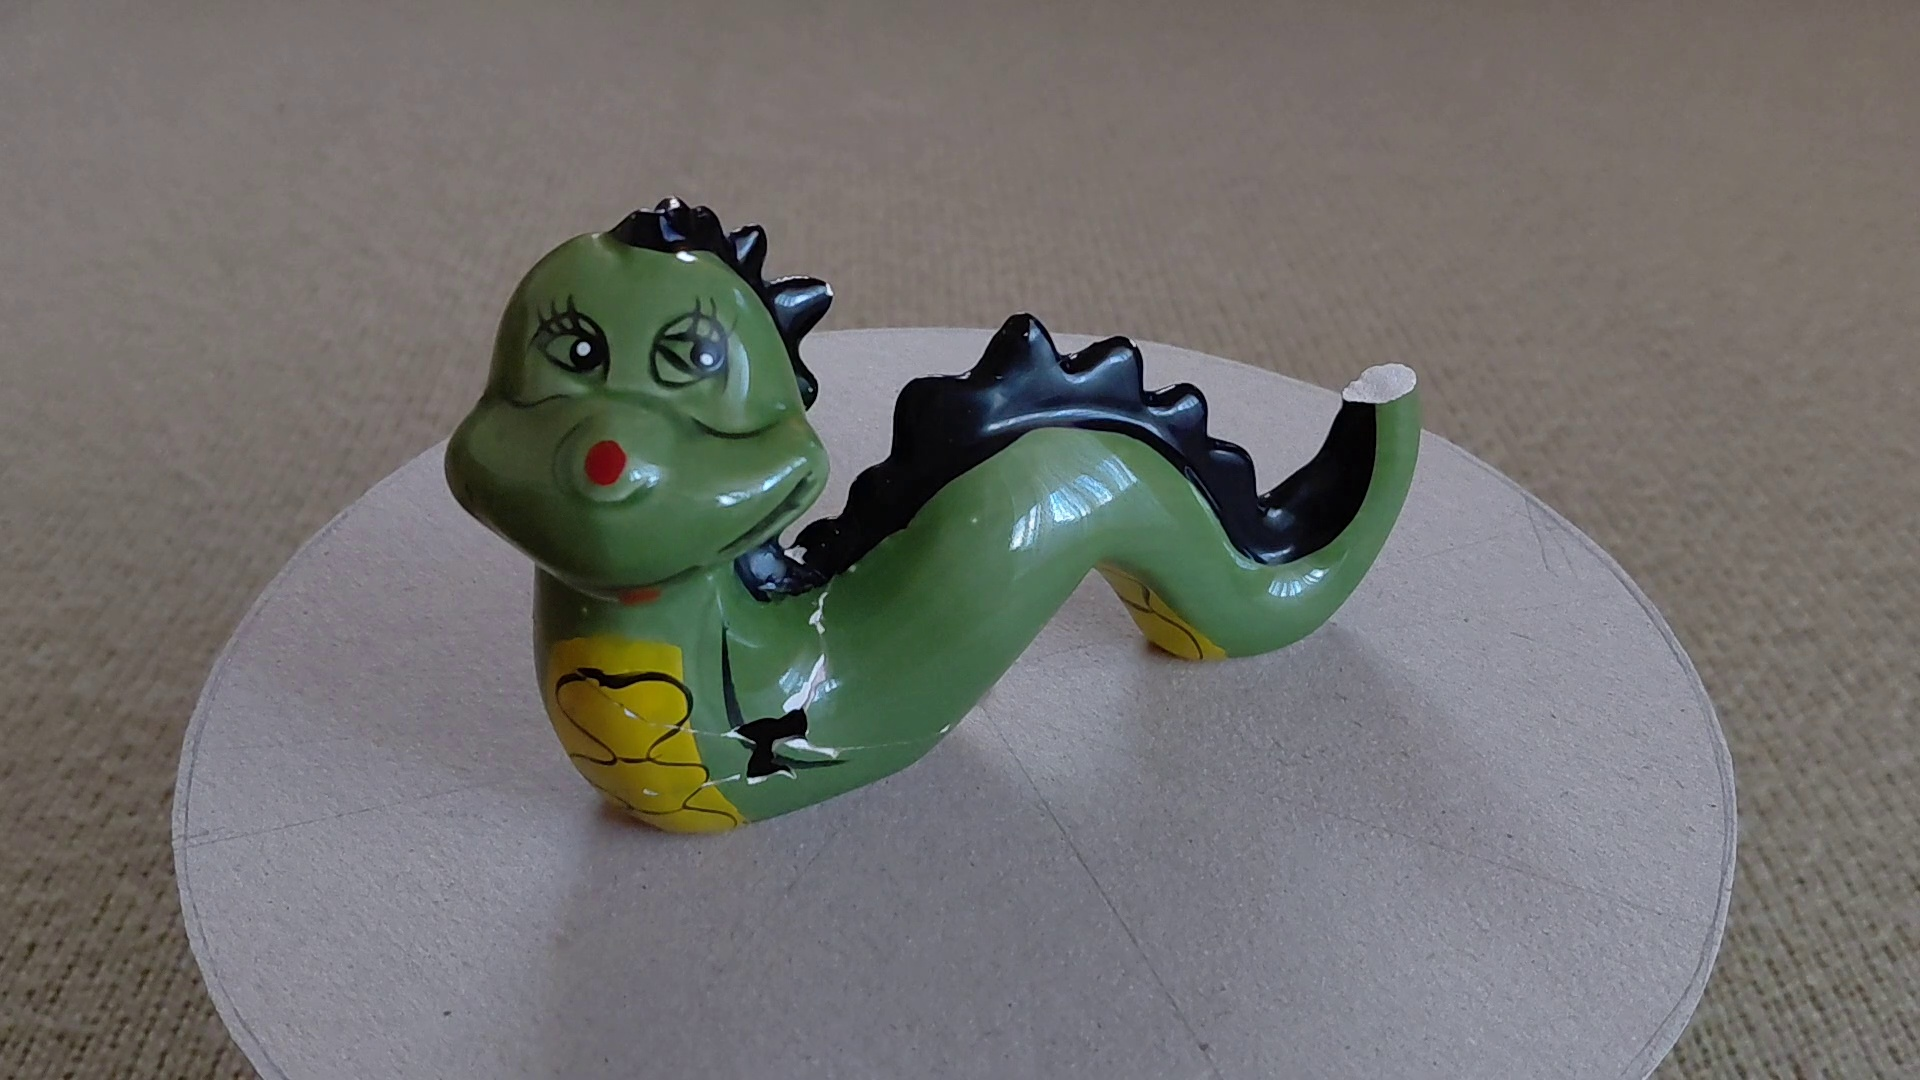

No previous synthetic comparison image was supplied; this is fine.


In [3]:
for folder in (RAW_DIR, CANDIDATE_DIR, SELECTED_DIR):
    folder.mkdir(parents=True, exist_ok=True)

if not INPUT_IMAGE.exists():
    raise FileNotFoundError(f"Place the damaged photograph at {INPUT_IMAGE}")

source_image = Image.open(INPUT_IMAGE).convert("RGB")
shutil.copy2(INPUT_IMAGE, RUN_DIR / "pogo_incomplete.png")

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

print("Damaged input size:", source_image.size)
print("Damaged input SHA-256:", sha256_file(INPUT_IMAGE))

if PREVIOUS_SYNTHETIC.exists():
    previous = Image.open(PREVIOUS_SYNTHETIC).convert("RGB")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(source_image)
    axes[0].set_title("Measured photograph of damaged object")
    axes[1].imshow(previous)
    axes[1].set_title("Previous synthetic reference — comparison only")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()
    plt.show()
else:
    display(source_image)
    print("No previous synthetic comparison image was supplied; this is fine.")


In [4]:
def _dilate(mask: np.ndarray, radius: int) -> np.ndarray:
    radius = max(0, int(round(radius)))
    if radius == 0:
        return mask.astype(bool, copy=True)
    image = Image.fromarray(mask.astype(np.uint8) * 255, mode="L")
    return np.asarray(image.filter(ImageFilter.MaxFilter(2 * radius + 1))) > 0


def _erode(mask: np.ndarray, radius: int) -> np.ndarray:
    radius = max(0, int(round(radius)))
    if radius == 0:
        return mask.astype(bool, copy=True)
    image = Image.fromarray(mask.astype(np.uint8) * 255, mode="L")
    return np.asarray(image.filter(ImageFilter.MinFilter(2 * radius + 1))) > 0


def _binary_close(mask: np.ndarray, radius: int) -> np.ndarray:
    return _erode(_dilate(mask, radius), radius)


def _binary_open(mask: np.ndarray, radius: int) -> np.ndarray:
    return _dilate(_erode(mask, radius), radius)


def _connected_components(mask: np.ndarray) -> list[np.ndarray]:
    """Return 4-connected components as arrays of (y, x) coordinates."""
    mask = np.asarray(mask, dtype=bool)
    image_height, image_width = mask.shape
    visited = np.zeros_like(mask, dtype=bool)
    components = []

    for start_y, start_x in np.argwhere(mask):
        if visited[start_y, start_x]:
            continue

        queue = deque([(int(start_y), int(start_x))])
        visited[start_y, start_x] = True
        coordinates = []

        while queue:
            y, x = queue.popleft()
            coordinates.append((y, x))
            for next_y, next_x in ((y - 1, x), (y + 1, x), (y, x - 1), (y, x + 1)):
                if (
                    0 <= next_y < image_height
                    and 0 <= next_x < image_width
                    and mask[next_y, next_x]
                    and not visited[next_y, next_x]
                ):
                    visited[next_y, next_x] = True
                    queue.append((next_y, next_x))

        components.append(np.asarray(coordinates, dtype=np.int32))

    return components


def _largest_component(mask: np.ndarray) -> np.ndarray:
    components = _connected_components(mask)
    if not components:
        raise ValueError("No foreground object could be segmented from the border background.")
    largest = max(components, key=len)
    result = np.zeros_like(mask, dtype=bool)
    result[largest[:, 0], largest[:, 1]] = True
    return result


def automatic_fracture_mask(
    image: Image.Image,
) -> tuple[Image.Image, dict, pd.DataFrame, dict]:
    """Locate a pale exposed fracture and build a scale/rotation-aware tip mask."""
    rgb = np.asarray(image.convert("RGB"), dtype=np.float32)
    image_height, image_width = rgb.shape[:2]

    border = max(
        4,
        int(round(min(image_width, image_height) * AUTO_BACKGROUND_BORDER_FRACTION)),
    )
    border_pixels = np.concatenate(
        [
            rgb[:border].reshape(-1, 3),
            rgb[-border:].reshape(-1, 3),
            rgb[:, :border].reshape(-1, 3),
            rgb[:, -border:].reshape(-1, 3),
        ],
        axis=0,
    )
    background_rgb = np.median(border_pixels, axis=0)
    border_distances = np.linalg.norm(border_pixels - background_rgb, axis=1)
    background_threshold = max(
        AUTO_BACKGROUND_MIN_DISTANCE,
        float(np.percentile(border_distances, 99.5) + 12.0),
    )

    colour_distance = np.linalg.norm(rgb - background_rgb, axis=2)
    object_mask = colour_distance > background_threshold
    object_mask = _binary_close(object_mask, radius=2)
    object_mask = _binary_open(object_mask, radius=1)
    object_mask = _largest_component(object_mask)
    object_area = int(object_mask.sum())

    maximum = rgb.max(axis=2)
    minimum = rgb.min(axis=2)
    saturation = (maximum - minimum) / np.maximum(maximum, 1.0)
    value = maximum
    pale = (
        object_mask
        & (value >= AUTO_PALE_VALUE_MIN)
        & (saturation <= AUTO_PALE_SATURATION_MAX)
    )

    # Small dilation groups anti-aliased pixels belonging to the same surface.
    grouped_pale = _dilate(pale, radius=3)
    boundary = object_mask & ~_erode(object_mask, radius=4)
    near_boundary = _dilate(boundary, radius=4)

    hint_xy = None
    if FRACTURE_HINT_NORMALIZED is not None:
        hint_x, hint_y = FRACTURE_HINT_NORMALIZED
        if not (0.0 <= hint_x <= 1.0 and 0.0 <= hint_y <= 1.0):
            raise ValueError("FRACTURE_HINT_NORMALIZED must contain values in [0, 1].")
        hint_xy = np.array([hint_x * image_width, hint_y * image_height], dtype=float)

    object_y, object_x = np.nonzero(object_mask)
    object_diagonal = float(
        np.hypot(object_x.max() - object_x.min() + 1, object_y.max() - object_y.min() + 1)
    )
    candidate_rows = []
    candidate_coordinates = {}

    for component_id, grouped_coordinates in enumerate(_connected_components(grouped_pale)):
        grouped_y = grouped_coordinates[:, 0]
        grouped_x = grouped_coordinates[:, 1]
        keep = pale[grouped_y, grouped_x]
        coordinates = grouped_coordinates[keep]
        area = int(len(coordinates))
        if area < AUTO_MIN_COMPONENT_AREA_PX or area > 0.04 * object_area:
            continue

        y = coordinates[:, 0]
        x = coordinates[:, 1]
        left, right = int(x.min()), int(x.max())
        top, bottom = int(y.min()), int(y.max())
        bbox_area = (right - left + 1) * (bottom - top + 1)
        compactness = float(area / bbox_area)
        boundary_fraction = float(near_boundary[y, x].mean())
        whiteness = float(((value[y, x] / 255.0) * (1.0 - saturation[y, x])).mean())
        center_xy = np.array([x.mean(), y.mean()], dtype=float)

        score = (
            np.sqrt(area)
            * (0.15 + boundary_fraction) ** 2
            * (0.50 + whiteness)
            * compactness
        )
        hint_distance_normalized = None
        if hint_xy is not None:
            hint_distance_normalized = float(
                np.linalg.norm(center_xy - hint_xy) / max(object_diagonal, 1.0)
            )
            score *= 1.0 + 3.0 * np.exp(-0.5 * (hint_distance_normalized / 0.10) ** 2)

        candidate_rows.append(
            {
                "component_id": int(component_id),
                "score": float(score),
                "area_px": area,
                "boundary_fraction": boundary_fraction,
                "compactness": compactness,
                "whiteness": whiteness,
                "center_x": float(center_xy[0]),
                "center_y": float(center_xy[1]),
                "bbox_left": left,
                "bbox_top": top,
                "bbox_right": right,
                "bbox_bottom": bottom,
                "hint_distance_normalized": hint_distance_normalized,
            }
        )
        candidate_coordinates[int(component_id)] = coordinates

    if not candidate_rows:
        raise RuntimeError(
            "Automatic mask detection found no plausible pale boundary fracture. "
            "Check the plain background/lighting, relax the AUTO_PALE thresholds, "
            "or use MASK_MODE='custom'."
        )

    candidates = pd.DataFrame(candidate_rows).sort_values("score", ascending=False).reset_index(drop=True)
    eligible = candidates[
        (candidates["boundary_fraction"] >= AUTO_MIN_BOUNDARY_FRACTION)
        & (candidates["compactness"] >= AUTO_MIN_COMPACTNESS)
    ].copy()
    if eligible.empty:
        raise RuntimeError(
            "Pale regions were found, but none looks like a compact exposed fracture surface. "
            "Use FRACTURE_HINT_NORMALIZED or MASK_MODE='custom'."
        )

    selected = eligible.iloc[0]
    second_score = float(eligible.iloc[1]["score"]) if len(eligible) > 1 else None
    confidence_ratio = (
        float(selected["score"] / second_score)
        if second_score is not None and second_score > 0
        else None
    )
    if (
        hint_xy is None
        and confidence_ratio is not None
        and confidence_ratio < AUTO_CONFIDENCE_RATIO
    ):
        best_centers = eligible.head(3)[["center_x", "center_y", "score"]].to_dict("records")
        raise RuntimeError(
            "Automatic fracture detection is ambiguous "
            f"(best/second score ratio={confidence_ratio:.2f}; candidates={best_centers}). "
            "Set FRACTURE_HINT_NORMALIZED near the fracture or use MASK_MODE='custom'."
        )

    selected_id = int(selected["component_id"])
    fracture_yx = candidate_coordinates[selected_id]
    fracture_xy = fracture_yx[:, [1, 0]].astype(float)
    fracture_center = fracture_xy.mean(axis=0)

    centered = fracture_xy - fracture_center
    covariance = centered.T @ centered / max(len(centered) - 1, 1)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    cross_axis = eigenvectors[:, int(np.argmax(eigenvalues))]
    if cross_axis[0] < 0:
        cross_axis *= -1.0
    cross_axis /= max(np.linalg.norm(cross_axis), 1e-8)

    cross_projections = centered @ cross_axis
    base_width = float(
        np.percentile(cross_projections, 97.5) - np.percentile(cross_projections, 2.5)
    )
    if base_width < 6.0:
        raise RuntimeError("The selected fracture is too small to estimate a stable cross-section.")

    # The fracture normal has two possible signs. The local foreground centroid
    # identifies which side contains the surviving tail; generation proceeds in
    # the opposite direction.
    object_xy = np.column_stack([object_x, object_y]).astype(float)
    local_radius = max(30.0, 2.4 * base_width)
    local_squared_distance = ((object_xy - fracture_center) ** 2).sum(axis=1)
    local_object_xy = object_xy[local_squared_distance <= local_radius**2]
    if len(local_object_xy) < 20:
        local_object_xy = object_xy
    local_body_center = local_object_xy.mean(axis=0)

    normal = np.array([-cross_axis[1], cross_axis[0]])
    inward_vector = local_body_center - fracture_center
    if float(normal @ inward_vector) < 0:
        normal *= -1.0
    inward_axis = normal / max(np.linalg.norm(normal), 1e-8)
    outward_axis = -inward_axis

    length = AUTO_MASK_LENGTH_BASE_WIDTHS * base_width
    overlap = AUTO_MASK_OVERLAP_BASE_WIDTHS * base_width
    distances = np.linspace(-overlap, length, 28)
    progress = np.clip(distances / max(length, 1e-8), 0.0, 1.0)
    curvature = (
        AUTO_MASK_CURVATURE_BASE_WIDTHS
        * base_width
        * progress**2
    )
    centerline = (
        fracture_center[None, :]
        + distances[:, None] * outward_axis[None, :]
        + curvature[:, None] * cross_axis[None, :]
    )
    half_width = (
        0.5
        * base_width
        * AUTO_MASK_WIDTH_SCALE
        * np.where(distances <= 0, 1.0, (1.0 - progress) ** 0.72)
    )
    half_width[-1] = 0.0

    side_a = centerline + half_width[:, None] * cross_axis[None, :]
    side_b = centerline - half_width[:, None] * cross_axis[None, :]
    polygon = np.vstack([side_a, side_b[::-1]])
    polygon[:, 0] = np.clip(polygon[:, 0], 0, image_width - 1)
    polygon[:, 1] = np.clip(polygon[:, 1], 0, image_height - 1)
    polygon_px = [tuple(np.rint(point).astype(int)) for point in polygon]

    automatic_mask = Image.new("L", image.size, 0)
    ImageDraw.Draw(automatic_mask).polygon(polygon_px, fill=255)

    selected_pixels = np.zeros((image_height, image_width), dtype=bool)
    selected_pixels[fracture_yx[:, 0], fracture_yx[:, 1]] = True
    metadata = {
        "mode": "auto",
        "background_rgb": [float(value) for value in background_rgb],
        "background_distance_threshold": float(background_threshold),
        "fracture_component_id": selected_id,
        "fracture_center_xy": [float(value) for value in fracture_center],
        "fracture_base_width_px": base_width,
        "outward_axis_xy": [float(value) for value in outward_axis],
        "cross_axis_xy": [float(value) for value in cross_axis],
        "mask_length_px": float(length),
        "mask_overlap_px": float(overlap),
        "confidence_ratio": confidence_ratio,
        "fracture_hint_normalized": FRACTURE_HINT_NORMALIZED,
        "candidate_count": int(len(candidates)),
    }
    debug = {
        "object_boundary": boundary,
        "selected_pixels": selected_pixels,
        "fracture_center": fracture_center,
        "tip_center": centerline[-1],
    }
    return automatic_mask, metadata, candidates, debug


width, height = source_image.size
mask_mode = MASK_MODE.strip().lower()
auto_mask_metadata = None

if mask_mode == "auto":
    binary_mask, auto_mask_metadata, fracture_candidates, auto_debug = automatic_fracture_mask(
        source_image
    )
    fracture_candidates.to_csv(RUN_DIR / "fracture_detection_candidates.csv", index=False)
    display(fracture_candidates.head(10))
elif mask_mode == "custom":
    if CUSTOM_MASK_PATH is None:
        raise ValueError("Set CUSTOM_MASK_PATH when MASK_MODE='custom'.")
    custom_path = Path(CUSTOM_MASK_PATH)
    if not custom_path.exists():
        raise FileNotFoundError(custom_path)
    binary_mask = Image.open(custom_path).convert("L")
    if binary_mask.size != source_image.size:
        raise ValueError("The custom mask must exactly match the input image dimensions.")
    binary_mask = binary_mask.point(lambda pixel: 255 if pixel >= 128 else 0)
elif mask_mode == "polygon":
    binary_mask = Image.new("L", source_image.size, 0)
    polygon_px = [
        (round(x * width), round(y * height))
        for x, y in MASK_POLYGON_NORMALIZED
    ]
    ImageDraw.Draw(binary_mask).polygon(polygon_px, fill=255)
else:
    raise ValueError("MASK_MODE must be 'auto', 'custom', or 'polygon'.")

mask_array = np.asarray(binary_mask, dtype=np.uint8)
editable = mask_array > 0
editable_fraction = float(editable.mean())
if not 0.001 <= editable_fraction <= 0.35:
    raise ValueError(
        f"Mask covers {editable_fraction:.2%} of the image; inspect it before generation."
    )

# Feather inward only. No generated pixel can leak outside the authority mask.
blurred = np.asarray(
    binary_mask.filter(ImageFilter.GaussianBlur(FEATHER_RADIUS_PX)),
    dtype=np.uint8,
).copy()
feather_array = blurred.copy()
feather_array[~editable] = 0
feather_mask = Image.fromarray(feather_array, mode="L")

binary_mask.save(RUN_DIR / "restoration_mask_binary.png")
feather_mask.save(RUN_DIR / "restoration_mask_feathered.png")

source_rgba = source_image.convert("RGBA")
yellow = Image.new("RGBA", source_image.size, (255, 215, 40, 0))
yellow.putalpha(binary_mask.point(lambda pixel: 105 if pixel else 0))
overlay = Image.alpha_composite(source_rgba, yellow)
overlay.save(RUN_DIR / "mask_overlay.png")

if mask_mode == "auto":
    diagnostic = overlay.copy()
    magenta = Image.new("RGBA", source_image.size, (255, 0, 190, 0))
    selected_fracture = Image.fromarray(
        auto_debug["selected_pixels"].astype(np.uint8) * 180,
        mode="L",
    )
    magenta.putalpha(selected_fracture)
    diagnostic = Image.alpha_composite(diagnostic, magenta)
    diagnostic_draw = ImageDraw.Draw(diagnostic)
    center = tuple(np.rint(auto_debug["fracture_center"]).astype(int))
    tip = tuple(np.rint(auto_debug["tip_center"]).astype(int))
    diagnostic_draw.line([center, tip], fill=(0, 255, 255, 255), width=3)
    diagnostic_draw.ellipse(
        [center[0] - 5, center[1] - 5, center[0] + 5, center[1] + 5],
        outline=(0, 255, 255, 255),
        width=2,
    )
    diagnostic.save(RUN_DIR / "auto_mask_diagnostics.png")
    display(diagnostic)
    print(
        "Magenta = detected fracture surface; cyan = inferred outward direction; "
        "yellow = generated region."
    )
else:
    display(overlay)

print("Mask mode:", mask_mode)
print(f"Editable fraction: {editable_fraction:.2%}")
print("Yellow = model-generated region; everything else is pixel-locked.")


/tmp/ipykernel_64/1062463158.py:5: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(mask.astype(np.uint8) * 255, mode="L")
/tmp/ipykernel_64/1062463158.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(mask.astype(np.uint8) * 255, mode="L")


RuntimeError: Automatic fracture detection is ambiguous (best/second score ratio=1.10; candidates=[{'center_x': 816.3176470588236, 'center_y': 617.0235294117647, 'score': 2.4473205036674743}, {'center_x': 1357.1761006289307, 'center_y': 394.9182389937107, 'score': 2.229693478283605}, {'center_x': 789.6296296296297, 'center_y': 554.1481481481482, 'score': 1.6098945339600932}]). Set FRACTURE_HINT_NORMALIZED near the fracture or use MASK_MODE='custom'.

**Stop here and inspect the diagnostic before loading the 12B model.**

For automatic mode, the magenta pixels must cover the exposed fracture cap,
the cyan line must point away from the surviving tail, and the yellow region
must overlap the fracture slightly and taper outward. If the wrong pale region
was selected, set a coarse `FRACTURE_HINT_NORMALIZED = (x, y)` in Cell 3 and
rerun Cells 3–5. If the geometry is still wrong, use `MASK_MODE = "custom"`.
Never continue merely because the detector returned a mask.


In [5]:
def padded_mask_box(mask: Image.Image, padding: int) -> tuple[int, int, int, int]:
    bbox = mask.getbbox()
    if bbox is None:
        raise ValueError("The restoration mask is empty.")
    left, top, right, bottom = bbox
    image_width, image_height = mask.size
    return (
        max(0, left - padding),
        max(0, top - padding),
        min(image_width, right + padding),
        min(image_height, bottom + padding),
    )

def model_dimensions(
    size: tuple[int, int],
    max_area: int,
    max_side: int,
    multiple: int,
) -> tuple[int, int]:
    crop_width, crop_height = size
    scale = min(
        (max_area / (crop_width * crop_height)) ** 0.5,
        max_side / max(crop_width, crop_height),
        2.0,
    )
    model_width = max(multiple, int(crop_width * scale) // multiple * multiple)
    model_height = max(multiple, int(crop_height * scale) // multiple * multiple)
    return model_width, model_height

crop_box = (
    padded_mask_box(binary_mask, CROP_PADDING_PX)
    if AUTO_CROP_TO_MASK
    else (0, 0, source_image.width, source_image.height)
)
source_crop = source_image.crop(crop_box)
mask_crop = binary_mask.crop(crop_box)
working_size = model_dimensions(
    source_crop.size,
    MODEL_MAX_AREA,
    MODEL_MAX_SIDE,
    MODEL_SIZE_MULTIPLE,
)
working_source = source_crop.resize(working_size, Image.Resampling.LANCZOS)
working_mask = mask_crop.resize(working_size, Image.Resampling.NEAREST)

working_source.save(RUN_DIR / "model_input_crop.png")
working_mask.save(RUN_DIR / "model_input_mask.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(working_source)
axes[0].set_title(f"Model image {working_size}")
axes[1].imshow(working_mask, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Mask supplied to FluxFillPipeline")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

print("Full image size:", source_image.size)
print("Crop box:", crop_box)
print("Crop size:", source_crop.size)
print("Model working size:", working_size)


NameError: name 'binary_mask' is not defined

## Load the gated model in NF4 4-bit

Both the 12B Fill transformer and the large T5 text encoder are loaded
in bitsandbytes NF4 with double quantization. Other components stay in
BF16. The persistent cache avoids repeating the large download.

Do not delete the cache after an interrupted download; rerunning this
cell can reuse verified shards.


In [6]:
hf_token = os.environ.get("HF_TOKEN") or get_token()
if not hf_token:
    raise RuntimeError(
        "No Hugging Face token is available. Accept access for "
        f"{MODEL_ID}, export HF_TOKEN on the host, and recreate the container."
    )

account = whoami(token=hf_token)
print("Authenticated Hugging Face account:", account.get("name", "unknown"))

gc.collect()
torch.cuda.empty_cache()

transformer_quantization = DiffusersBitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

text_quantization = TransformersBitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Load and quantize T5 entirely on CPU.
# bitsandbytes 0.50.1 supports its multi-backend CPU path.
print("Loading T5 encoder in 4-bit on CPU...")

text_encoder_2 = T5EncoderModel.from_pretrained(
    MODEL_ID,
    subfolder="text_encoder_2",
    quantization_config=text_quantization,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    device_map={"": "cpu"},
    token=hf_token,
)

gc.collect()
torch.cuda.empty_cache()

# Diffusers performs the transformer quantization on CUDA.
print("Loading FLUX transformer in 4-bit on CUDA...")

transformer = FluxTransformer2DModel.from_pretrained(
    MODEL_ID,
    subfolder="transformer",
    quantization_config=transformer_quantization,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    token=hf_token,
)

# Immediately free GPU memory before constructing the complete pipeline.
print("Moving quantized transformer to CPU...")
transformer.to("cpu")

gc.collect()
torch.cuda.empty_cache()

print(
    "VRAM after staged loading:",
    f"{torch.cuda.memory_allocated() / 2**30:.2f} GiB",
)

pipe = FluxFillPipeline.from_pretrained(
    MODEL_ID,
    transformer=transformer,
    text_encoder_2=text_encoder_2,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    token=hf_token,
)

if getattr(pipe, "hf_device_map", None) is not None:
    pipe.reset_device_map()

#if OFFLOAD_MODE == "sequential":
#    pipe.enable_sequential_cpu_offload(device="cuda")
#elif OFFLOAD_MODE == "model":
#    pipe.enable_model_cpu_offload(device="cuda")
#else:
#    raise ValueError("OFFLOAD_MODE must be 'model' or 'sequential'.")

assert OFFLOAD_MODE == "model"

pipe.enable_model_cpu_offload(device="cuda")
print("Installed model CPU offload")


pipe.vae.enable_tiling()
pipe.vae.enable_slicing()
pipe.set_progress_bar_config(disable=False)

print("Pipeline loaded successfully.")



def footprint_gib(module) -> float | None:
    getter = getattr(module, "get_memory_footprint", None)
    return None if getter is None else getter() / 2**30

print("Pipeline:", type(pipe).__name__)
print("Model:", MODEL_ID)
print("Offload mode:", OFFLOAD_MODE)
print("Transformer reports 4-bit:", getattr(transformer, "is_loaded_in_4bit", False))
print("T5 reports 4-bit:", getattr(text_encoder_2, "is_loaded_in_4bit", False))
print("Transformer parameter footprint GiB:", footprint_gib(transformer))
print("T5 parameter footprint GiB:", footprint_gib(text_encoder_2))


`torch_dtype` is deprecated! Use `dtype` instead!


Authenticated Hugging Face account: yuliadm-hf
Loading T5 encoder in 4-bit on CPU...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

text_encoder_2/model-00001-of-00002.safe(…):   0%|          | 0.00/4.99G [00:00<?, ?B/s]

text_encoder_2/model-00002-of-00002.safe(…):   0%|          | 0.00/4.53G [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/774 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Installed model CPU offload
Pipeline loaded successfully.
Pipeline: FluxFillPipeline
Model: black-forest-labs/FLUX.1-Fill-dev
Offload mode: model
Transformer reports 4-bit: True
T5 reports 4-bit: True
Transformer parameter footprint GiB: 5.546793103218079
T5 parameter footprint GiB: 5.682994842529297


In [ ]:



hook_types = set()

for component_name in (
    "text_encoder",
    "text_encoder_2",
    "transformer",
    "vae",
):
    component = getattr(pipe, component_name, None)
    if component is None:
        continue

    for module in component.modules():
        hook = getattr(module, "_hf_hook", None)
        if hook is not None:
            hook_types.add(type(hook).__name__)

print("Installed hook types:", sorted(hook_types))

assert "AlignDevicesHook" not in hook_types, (
    "Sequential-offload hooks are still installed. Restart the kernel "
    "and rebuild the pipeline using model CPU offload."
)














source_np = np.asarray(source_image, dtype=np.uint8)
alpha = np.asarray(feather_mask, dtype=np.float32)[..., None] / 255.0
candidate_records = []
constrained_images = {}

crop_left, crop_top, crop_right, crop_bottom = crop_box

for seed in SEEDS:
    raw_path = RAW_DIR / f"seed_{seed:06d}_raw_full.png"
    constrained_path = CANDIDATE_DIR / f"seed_{seed:06d}_intact_hypothesis.png"

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    generator = torch.Generator(device="cpu").manual_seed(seed)
    started = time.perf_counter()

    with torch.inference_mode():
        generated_working = pipe(
            prompt=PROMPT,
            image=working_source,
            mask_image=working_mask,
            height=working_size[1],
            width=working_size[0],
            guidance_scale=GUIDANCE_SCALE,
            num_inference_steps=NUM_INFERENCE_STEPS,
            max_sequence_length=MAX_SEQUENCE_LENGTH,
            generator=generator,
        ).images[0].convert("RGB")

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    peak_vram_gib = torch.cuda.max_memory_allocated() / 2**30

    generated_crop = generated_working.resize(source_crop.size, Image.Resampling.LANCZOS)
    raw_full = source_image.copy()
    raw_full.paste(generated_crop, (crop_left, crop_top))
    raw_full.save(raw_path)

    generated_np = np.asarray(raw_full, dtype=np.uint8)
    blended = np.rint(
        source_np.astype(np.float32) * (1.0 - alpha)
        + generated_np.astype(np.float32) * alpha
    ).clip(0, 255).astype(np.uint8)

    # Absolute evidence boundary: protected pixels are copied byte-for-byte.
    blended[~editable] = source_np[~editable]
    constrained = Image.fromarray(blended, mode="RGB")

    png_info = PngImagePlugin.PngInfo()
    png_info.add_text("fuse_asset_type", "synthetic_intact_reference_hypothesis")
    png_info.add_text("fuse_model", MODEL_ID)
    png_info.add_text("fuse_pipeline", "FluxFillPipeline")
    png_info.add_text("fuse_quantization", "NF4 4-bit double-quant")
    png_info.add_text("fuse_seed", str(seed))
    png_info.add_text("fuse_source_sha256", sha256_file(INPUT_IMAGE))
    constrained.save(constrained_path, pnginfo=png_info)

    constrained_np = np.asarray(constrained, dtype=np.uint8)
    outside_difference = np.abs(
        constrained_np.astype(np.int16) - source_np.astype(np.int16)
    )[~editable]
    inside_difference = np.abs(
        constrained_np.astype(np.int16) - source_np.astype(np.int16)
    )[editable]

    candidate_records.append(
        {
            "seed": int(seed),
            "raw_path": str(raw_path),
            "constrained_path": str(constrained_path),
            "elapsed_seconds": elapsed,
            "peak_vram_gib": peak_vram_gib,
            "outside_mask_max_abs_difference": int(outside_difference.max(initial=0)),
            "inside_mask_mean_abs_difference": float(inside_difference.mean()),
        }
    )
    constrained_images[seed] = constrained
    print(
        f"seed={seed} time={elapsed:.1f}s peak_vram={peak_vram_gib:.2f} GiB "
        f"outside_max={candidate_records[-1]['outside_mask_max_abs_difference']}"
    )
    gc.collect()
    torch.cuda.empty_cache()

records_frame = pd.DataFrame(candidate_records)
display(records_frame)

if not (records_frame["outside_mask_max_abs_difference"] == 0).all():
    raise AssertionError("At least one candidate changed protected source pixels.")


In [ ]:
figure_columns = min(3, len(SEEDS) + 1)
figure_rows = int(np.ceil((len(SEEDS) + 1) / figure_columns))
fig, axes = plt.subplots(figure_rows, figure_columns, figsize=(6 * figure_columns, 5 * figure_rows))
axes = np.atleast_1d(axes).reshape(-1)

axes[0].imshow(source_image)
axes[0].set_title("Damaged measured photograph")
axes[0].axis("off")

for axis, seed in zip(axes[1:], SEEDS):
    axis.imshow(constrained_images[seed])
    axis.set_title(f"FLUX.1 Fill hypothesis — seed {seed}")
    axis.axis("off")

for axis in axes[len(SEEDS) + 1:]:
    axis.axis("off")

plt.tight_layout()
candidate_grid_path = RUN_DIR / "candidate_grid.png"
plt.savefig(candidate_grid_path, dpi=160, bbox_inches="tight")
plt.show()
print("Candidate grid:", candidate_grid_path)


In [ ]:
candidate_stack = np.stack(
    [np.asarray(constrained_images[seed], dtype=np.float32) for seed in SEEDS],
    axis=0,
)
disagreement = candidate_stack.var(axis=0).mean(axis=2)
editable_values = disagreement[editable]
scale = max(float(np.percentile(editable_values, 99)), 1e-6)
normalized = np.clip(disagreement / scale, 0.0, 1.0)

magma = plt.get_cmap("magma")(normalized)[..., :3]
disagreement_rgb = np.rint(magma * 255).astype(np.uint8)
disagreement_rgb[~editable] = np.rint(source_np[~editable] * 0.22).astype(np.uint8)
disagreement_image = Image.fromarray(disagreement_rgb, mode="RGB")
disagreement_path = RUN_DIR / "candidate_disagreement.png"
disagreement_image.save(disagreement_path)

display(disagreement_image)
print("Bright pixels indicate disagreement among generated hypotheses.")
print("This is an uncertainty proxy, not a calibrated probability.")


In [ ]:
if SELECTED_SEED not in constrained_images:
    raise ValueError(f"SELECTED_SEED must be one of {SEEDS}")

selected_path = SELECTED_DIR / f"selected_seed_{SELECTED_SEED:06d}.png"
constrained_images[SELECTED_SEED].save(selected_path)

manifest = {
    "schema_version": "fuse.reference_hypothesis.v2",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "asset_type": "synthetic_intact_reference_hypothesis",
    "authority": "human_selected_synthetic_prior_not_measured_evidence",
    "model": {
        "id": MODEL_ID,
        "pipeline": "FluxFillPipeline",
        "transformer_parameters": "12B",
        "transformer_quantization": "bitsandbytes NF4 4-bit double-quant",
        "text_encoder_2_quantization": "bitsandbytes NF4 4-bit double-quant",
        "compute_dtype": "bfloat16",
        "offload_mode": OFFLOAD_MODE,
    },
    "generation": {
        "num_inference_steps": NUM_INFERENCE_STEPS,
        "guidance_scale": GUIDANCE_SCALE,
        "max_sequence_length": MAX_SEQUENCE_LENGTH,
        "working_size": list(working_size),
        "crop_box_xyxy": list(crop_box),
        "mask_conditioned_during_generation": True,
    },
    "prompt": PROMPT,
    "input": {
        "path": str(INPUT_IMAGE),
        "sha256": sha256_file(INPUT_IMAGE),
        "size": list(source_image.size),
    },
    "mask": {
        "mode": mask_mode,
        "binary_path": str(RUN_DIR / "restoration_mask_binary.png"),
        "model_mask_path": str(RUN_DIR / "model_input_mask.png"),
        "feathered_path": str(RUN_DIR / "restoration_mask_feathered.png"),
        "diagnostics_path": (
            str(RUN_DIR / "auto_mask_diagnostics.png") if mask_mode == "auto" else None
        ),
        "candidate_table_path": (
            str(RUN_DIR / "fracture_detection_candidates.csv") if mask_mode == "auto" else None
        ),
        "editable_fraction": editable_fraction,
        "automatic_detection": auto_mask_metadata,
        "polygon_normalized": MASK_POLYGON_NORMALIZED if mask_mode == "polygon" else None,
        "custom_mask_path": (
            str(CUSTOM_MASK_PATH) if mask_mode == "custom" else None
        ),
        "outside_mask_pixels_exactly_preserved": True,
    },
    "seeds": [int(seed) for seed in SEEDS],
    "selected_seed": int(SELECTED_SEED),
    "selected_image": str(selected_path),
    "selected_sha256": sha256_file(selected_path),
    "candidate_records": candidate_records,
    "candidate_grid": str(candidate_grid_path),
    "uncertainty_proxy": str(disagreement_path),
    "previous_synthetic_used_for_generation": False,
}

manifest_path = RUN_DIR / "reference_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

display(constrained_images[SELECTED_SEED])
print("Selected candidate:", selected_path)
print("Manifest:", manifest_path)


In [ ]:
if PUBLISH_TO_HUNYUAN:
    HUNYUAN_INPUT.parent.mkdir(parents=True, exist_ok=True)
    if HUNYUAN_INPUT.exists():
        backup = HUNYUAN_INPUT.with_name(
            HUNYUAN_INPUT.stem
            + "_backup_"
            + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
            + HUNYUAN_INPUT.suffix
        )
        shutil.copy2(HUNYUAN_INPUT, backup)
        print("Backed up previous Hunyuan reference to:", backup)

    shutil.copy2(selected_path, HUNYUAN_INPUT)
    print("Published selected synthetic reference to:", HUNYUAN_INPUT)
else:
    print("Publishing is disabled.")
    print("Inspect all hypotheses, set SELECTED_SEED, then explicitly set PUBLISH_TO_HUNYUAN = True.")


## Interpretation

- The automatic CV step adapts the mask's location, scale and rotation to the
  detected fracture; it does not infer historical ground truth.
- The generated area is conditioned on both the source crop and the white
  restoration mask.
- Pixels outside the authoritative binary mask are restored exactly from the
  damaged photograph.
- Candidate disagreement highlights unstable synthetic geometry.
- Selection means “accepted intact-reference hypothesis,” not “verified
  original geometry.” Kaolin and later human review remain necessary.

On a 12 GB GPU, keep `OFFLOAD_MODE = "model"`. If inference still runs out of
VRAM, reduce `MODEL_MAX_SIDE`/`MODEL_MAX_AREA`, restart the kernel and rerun.
Sequential offload is intentionally excluded from this 4-bit path because it
can move bitsandbytes quantization state to PyTorch's `meta` device.
